In [1]:
import pandas as pd

caminho_dado = '/content/drive/MyDrive/Colab Notebooks/PIBIT USINA PETROLINA/Dados eficiência da Usina Petrolina.xlsx'
tipo_das_colunas = {'Time': str,
                    'Potência AC total (kW)': float,
                    'POA (W/m²)': float,
                    'Eficiência': float}

dados_brutos = pd.read_excel(caminho_dado,
                             dtype = tipo_das_colunas,             # Parâmetro principal: lê tudo como texto.
                             keep_default_na = False,              # Não converte valores como 'N/A' para NaN.
                             na_values = [''],                     # define que apenas células vazias devem ser consideradas NaN.
                             usecols = ['Time',
                                       'Potência AC total (kW)',
                                       'POA (W/m²)',
                                       'Eficiência'])

dados_brutos['Time'] = pd.to_datetime(dados_brutos['Time'])        # É e malhor pratica para coverter em datetime
dados_brutos.set_index('Time', inplace=True)                       # coluna Time como index para otimizar as terefas de serie temporal

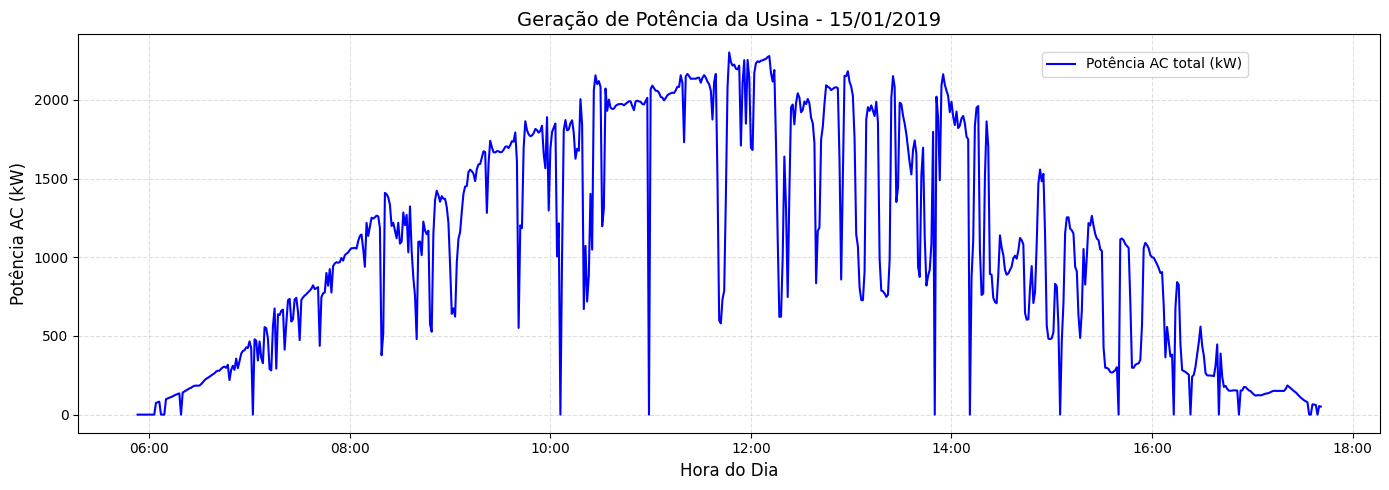

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates                                               #Biblioteca para formatar datas nos eixos
import pandas as pd

# SELECIONA DADOS
dados_do_dia = dados_brutos.loc['2019-01-15']
data_formatada = dados_do_dia.index[0].strftime('%d/%m/%Y')                     #Por no Gráfio

# CRIA FIGURA E GRAFICO
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dados_do_dia.index, dados_do_dia['Potência AC total (kW)'], label='Potência AC total (kW)', color='blue')

# ADICIONA MELHORIAS E FORMATAÇÃO
ax.set_title(f'Geração de Potência da Usina - {data_formatada}', fontsize=14)
ax.set_xlabel('Hora do Dia', fontsize=12)
ax.set_ylabel('Potência AC (kW)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))                     #Transforma as datas completas em horas e minutos legíveis
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))                      #Define que os marcadores principais no eixo X aparecerão a cada 2 horas

# AJUSTAR LAYOUT E EXIBIR
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
fig.tight_layout()

# SALVA
data_formatada = data_formatada.replace('/', '-')
nome_arquivo = f'Grafico_Potencia_{data_formatada}'
fig.savefig(f'/content/drive/MyDrive/Colab Notebooks/PIBIT USINA PETROLINA/{nome_arquivo}.png',
            dpi=300,
            bbox_inches='tight')

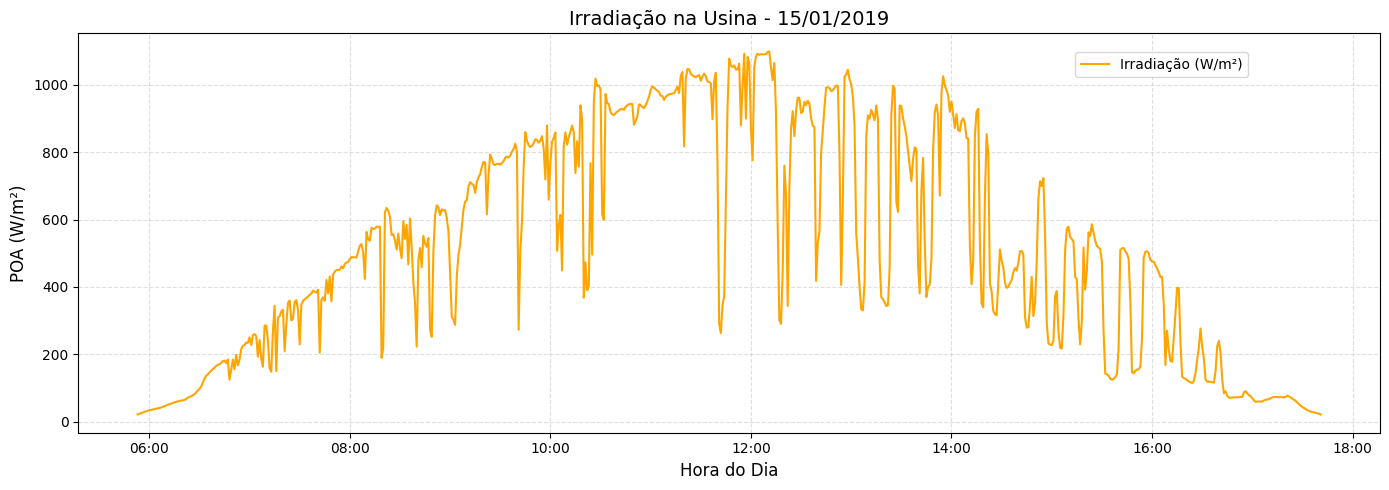

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates                                               #Biblioteca para formatar datas nos eixos
import pandas as pd

# SELECIONA DADOS
dados_do_dia = dados_brutos.loc['2019-01-15']
data_formatada = dados_do_dia.index[0].strftime('%d/%m/%Y')                     #Por no Gráfio

# CRIA FIGURA E GRAFICO
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dados_do_dia.index, dados_do_dia['POA (W/m²)'], label='Irradiação (W/m²)', color='orange')

# ADICIONA MELHORIAS E FORMATAÇÃO
ax.set_title(f'Irradiação na Usina - {data_formatada}', fontsize=14)
ax.set_xlabel('Hora do Dia', fontsize=12)
ax.set_ylabel('POA (W/m²)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))                     #Transforma as datas completas em horas e minutos legíveis
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))                      #Define que os marcadores principais no eixo X aparecerão a cada 2 horas

# AJUSTAR LAYOUT E EXIBIR
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
fig.tight_layout()

# SALVA
data_formatada = data_formatada.replace('/', '-')
nome_arquivo = f'Grafico_Irradiação_{data_formatada}'
fig.savefig(f'/content/drive/MyDrive/Colab Notebooks/PIBIT USINA PETROLINA/{nome_arquivo}.png',
            dpi=300,
            bbox_inches='tight')

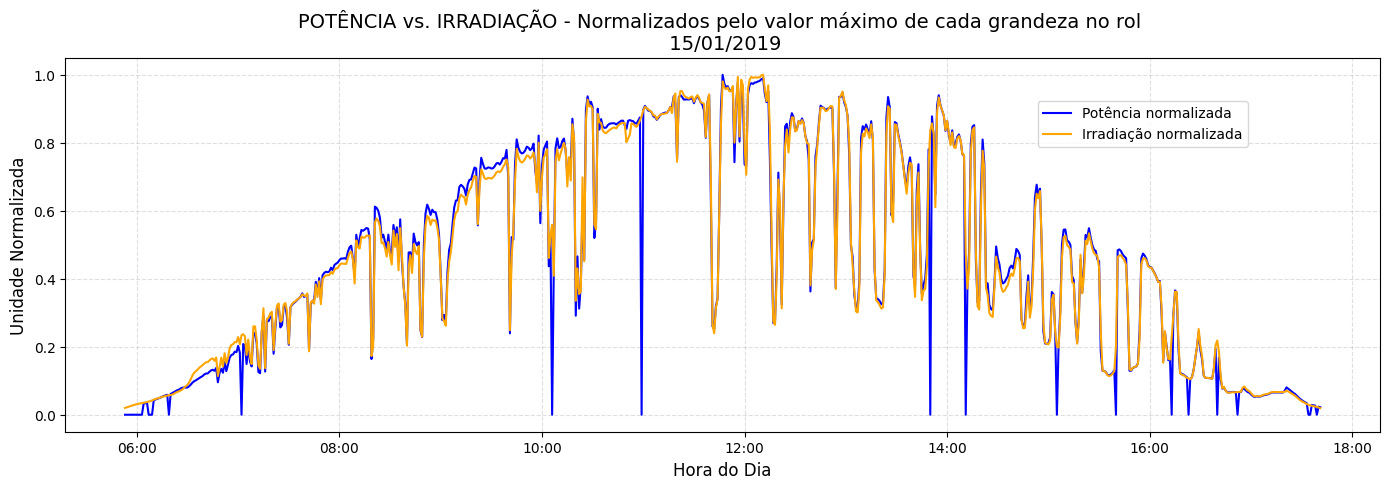

In [58]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates                                               #Biblioteca para formatar datas nos eixos
import pandas as pd

# SELECIONA DADOS
dados_do_dia = dados_brutos.loc['2019-01-15']
data_formatada = dados_do_dia.index[0].strftime('%d/%m/%Y')                     #Por no Gráfio

# CRIA FIGURA E GRAFICO
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dados_do_dia.index, dados_do_dia['Potência AC total (kW)']/dados_do_dia['Potência AC total (kW)'].max(), label='Potência normalizada', color='blue')
ax.plot(dados_do_dia.index, dados_do_dia['POA (W/m²)']/dados_do_dia['POA (W/m²)'].max(), label='Irradiação normalizada', color='orange')

# ADICIONA MELHORIAS E FORMATAÇÃO
ax.set_title(f'POTÊNCIA vs. IRRADIAÇÃO - Normalizados pelo valor máximo de cada grandeza no rol \n {data_formatada}', fontsize=14)
ax.set_xlabel('Hora do Dia', fontsize=12)
ax.set_ylabel('Unidade Normalizada', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))                     #Transforma as datas completas em horas e minutos legíveis
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))                      #Define que os marcadores principais no eixo X aparecerão a cada 2 horas

# AJUSTAR LAYOUT E EXIBIR
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.8))
fig.tight_layout()

# SALVA
data_formatada = data_formatada.replace('/', '-')
nome_arquivo = f'Grafico_Potência_Vs_Irradiação_Normalizados_{data_formatada}'
fig.savefig(f'/content/drive/MyDrive/Colab Notebooks/PIBIT USINA PETROLINA/{nome_arquivo}.png',
            dpi=300,
            bbox_inches='tight')

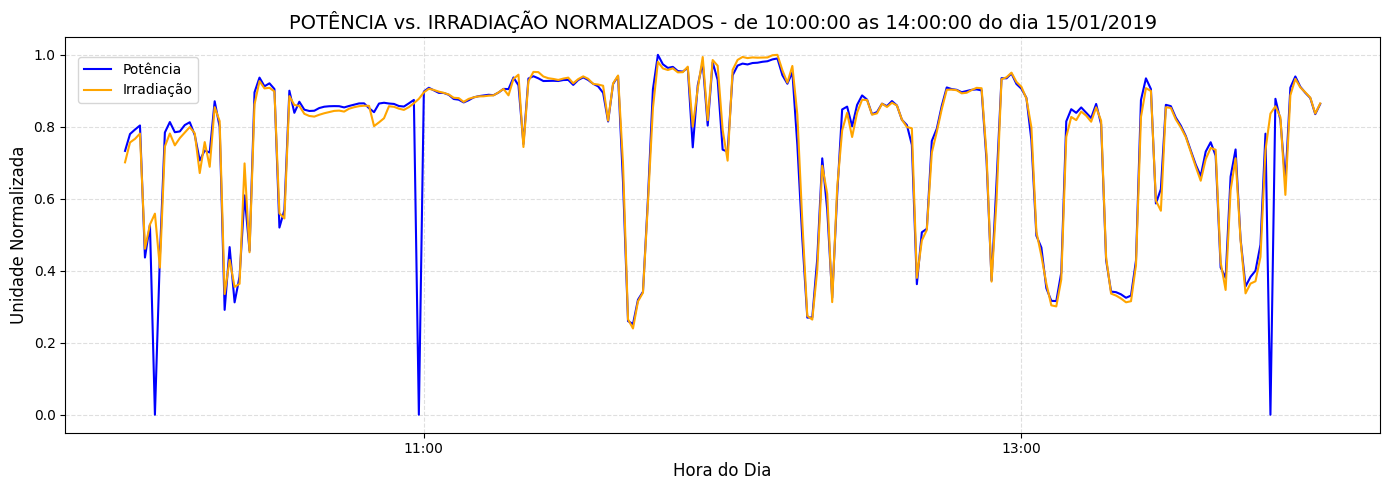

In [60]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates                                               #Biblioteca para formatar datas nos eixos
import pandas as pd

# SELECIONA DADOS
dados_do_dia = dados_brutos.loc['2019-01-15 10:00:00' : '2019-01-15 14:00:00']
data_formatada = dados_do_dia.index[0].strftime('%d/%m/%Y')                     #Por no Gráfio

# CRIA FIGURA E GRAFICO
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dados_do_dia.index, dados_do_dia['Potência AC total (kW)']/dados_do_dia['Potência AC total (kW)'].max(), label='Potência', color='blue')
ax.plot(dados_do_dia.index, dados_do_dia['POA (W/m²)']/dados_do_dia['POA (W/m²)'].max(), label='Irradiação', color='orange')

# ADICIONA MELHORIAS E FORMATAÇÃO
ax.set_title(f'POTÊNCIA vs. IRRADIAÇÃO NORMALIZADOS - de 10:00:00 as 14:00:00 do dia {data_formatada}', fontsize=14)
ax.set_xlabel('Hora do Dia', fontsize=12)
ax.set_ylabel('Unidade Normalizada', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))                     #Transforma as datas completas em horas e minutos legíveis
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))                      #Define que os marcadores principais no eixo X aparecerão a cada 2 horas

# AJUSTAR LAYOUT E EXIBIR
fig.legend(loc='upper right', bbox_to_anchor=(0.15, 0.89))
fig.tight_layout()

# SALVA
data_formatada = data_formatada.replace('/', '-')
nome_arquivo = f'Grafico_Potência_Vs_Irradiação_Normalizados_de 10:00:00_as_14:00:00_{data_formatada}'
fig.savefig(f'/content/drive/MyDrive/Colab Notebooks/PIBIT USINA PETROLINA/{nome_arquivo}.png',
            dpi=300,
            bbox_inches='tight')